This notebook will be largely for a statistical approach to exploring the data generated in DataImport

In [8]:
import pandas as pd
import scipy
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import researchpy

In [9]:
#Create DataFrame for analysis from the DataImport CSV
filename = r"C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\CS-3120-Project\GeneratedData\GeneratedMotorcycleData"

df = pd.read_csv(filename)

col_names = df.columns.tolist()
print(col_names)

['ST_CASE', 'VEH_NO', 'OWNER', 'J_KNIFE', 'TRAV_SP', 'DR_DRINK', 'L_STATUS', 'PREV_SPD', 'PREV_OTH', 'SPEEDREL', 'VE_TOTAL', 'VE_FORMS', 'HOUR', 'LGT_COND', 'RUR_URB', 'FUNC_SYS', 'HARM_EV', 'MAN_COLL', 'RELJCT2', 'TYP_INT', 'REL_ROAD', 'WEATHER', 'VEH_AGE', 'OTHER_VEH_SP', 'OTHER_VEH_AVG_WEIGHT']


# Data types<br>
## All of our features can be considered to be categorical for the sake of clustering. They fall into two types. <br>


In [10]:
#HOUR may seem to be ordinal, but we will adjust it later to be nominal
ordinal = ['TRAV_SP', 'PREV_SPD', 'PREV_OTH', 'VE_TOTAL', 'VE_FORMS', 'VEH_AGE', 'OTHER_VEH_SP', 'OTHER_VEH_AVG_WEIGHT']
nominal = ['OWNER', 'J_KNIFE', 'DR_DRINK', 'L_STATUS',  'HOUR', 'SPEEDREL', 'LGT_COND', 'RUR_URB', 'FUNC_SYS', 'HARM_EV', 'MAN_COLL', 'RELJCT2', 'TYP_INT', 'REL_ROAD', 'WEATHER'] 

## More Feature Cleaning

**Bin large ordinal categories**

In [11]:
#We take a look at the lowest and highest values for each ordinal feature, to understand which need to be binned

for col in ordinal:
    unique_vals = df[col].unique().tolist()
    unique_vals.sort()
    low = unique_vals[0]
    if unique_vals[-1] == 999: high = unique_vals[-2]
    else: high = unique_vals[-1]
    length = len(unique_vals)
    print(f"Column {col:<15} | highest_val: {str(high):<10} | lowest_val: {str(low):<10} | length: {length}")
    

Column TRAV_SP         | highest_val: 150        | lowest_val: 0          | length: 127
Column PREV_SPD        | highest_val: 9          | lowest_val: 0          | length: 11
Column PREV_OTH        | highest_val: 35         | lowest_val: 0          | length: 21
Column VE_TOTAL        | highest_val: 11         | lowest_val: 1          | length: 9
Column VE_FORMS        | highest_val: 11         | lowest_val: 1          | length: 9
Column VEH_AGE         | highest_val: 70.0       | lowest_val: -2.0       | length: 63
Column OTHER_VEH_SP    | highest_val: 130.0      | lowest_val: 0.0        | length: 95
Column OTHER_VEH_AVG_WEIGHT | highest_val: 18.0       | lowest_val: 11.0       | length: 12


In [12]:
#TRAV_SP by 5 mph bins
binned_vals = np.ceil(df['TRAV_SP'] / 5) * 5
print(binned_vals.unique().tolist())

# 2. Assign the new values and cast to the "Int64" (nullable) dtype
df['TRAV_SP'] = pd.Series(np.where(df['TRAV_SP'] == 0, 0, binned_vals)).astype("Int64") 

[60.0, 1000.0, 75.0, 55.0, 40.0, 30.0, 0.0, 70.0, 25.0, 85.0, 120.0, 35.0, 45.0, 20.0, 90.0, 65.0, 10.0, 50.0, 100.0, 15.0, 80.0, 95.0, 5.0, 125.0, 140.0, 110.0, 130.0, 105.0, 115.0, 150.0, 145.0, 135.0]


In [13]:
#The previous step changes all 999 values to 1000, we'll fix that here so 999 still represents unknown values
df['TRAV_SP'] = df['TRAV_SP'].replace(1000,999)

In [14]:
#OTHER_VEH_SP by 5 mph bins
binned_vals2 = np.ceil(df['OTHER_VEH_SP'] / 5) * 5
new_vals = np.where(
    df['OTHER_VEH_SP'].isna(),  # Condition 1: Is the value NaN?
    pd.NA,                 # If yes, set it to pandas' NA
    np.where(              # If no, run your original logic
        df['OTHER_VEH_SP'] == 0,
        0,
        binned_vals2
    )
)

# 2. Assign the new values and cast to the "Int64" (nullable) dtype
df['OTHER_VEH_SP'] = pd.Series(new_vals).astype("Int64")

In [15]:
#Replace 1000 with 999 
df['OTHER_VEH_SP'] = df['OTHER_VEH_SP'].replace(1000,999)

In [16]:
binned_vals3 = np.ceil(df['VEH_AGE'] / 10) * 10
df['VEH_AGE'] = np.where(df['VEH_AGE'] == 0, 0, binned_vals3).astype(int) 
df['VEH_AGE'] = df['VEH_AGE'].replace(1000,999)

Replace 999 with NaN across dataset to avoid including unknowns in future analysis

In [17]:

df = df.replace(999, np.nan)

**Convert 'HOUR' to nominal data**

In [18]:
print(df['HOUR'].unique().tolist())

[0.0, 12.0, 19.0, 21.0, 15.0, 16.0, 20.0, 13.0, 11.0, 17.0, 14.0, 9.0, 2.0, 23.0, 7.0, 10.0, 18.0, 4.0, 8.0, 22.0, 6.0, 5.0, 3.0, nan, 1.0]


In [19]:
def hourBins(row):
    hour = row['HOUR']

    if pd.isna(hour):
        return hour
    elif 0 <= hour <= 4:
        return 'midnight'
    elif 5 <= hour <= 7:
        return 'early morning'
    elif 8 <= hour <= 11:
        return 'morning rush'
    elif 12 <= hour <= 14:
        return 'noon'
    elif 15 <= hour <= 18:
        return 'evening rush'
    elif 19 <= hour <= 21:
        return 'evening'
    elif 22 <= hour <= 23:
        return 'late evening'




In [20]:
df['HOUR'] = df.apply(hourBins, 1)

## Spearman's Rank Correlation

**Spearman's Rank** is a correlation test best suited for ordinal data, as it assumes that the categories have some order but makes no assumptions about the distance between "ranks"

In [21]:
df_ordinal = df[ordinal]

In [26]:
spearman_matrix = df_ordinal.corr(method='spearman')

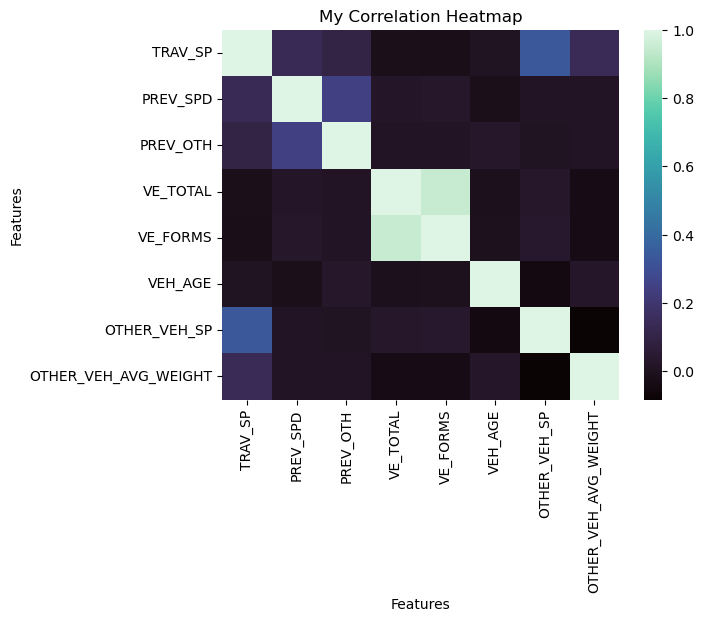

In [27]:
ax = sns.heatmap(spearman_matrix, cmap='mako' )
ax.set_title("My Correlation Heatmap")
ax.set_xlabel("Features")
ax.set_ylabel("Features")
# 2. Display the plot
plt.show()


**Analysis of Spearman's Rank correlations for ordinal features:**<br>
There are almost no meaningful correlations. VE_TOTAL and VE_FORMS are not independent features, as they both measure different aspects of how many vehicles were involved in the accident. PREV_SPD and PREV_OTH both track the number of past traffic violations, so its not suprising that they would be related. <br>


## Chi Squared Correlation Testing 

**Chi-Squared** is best suited to nominal data as it 

In [23]:
from scipy.stats import chi2_contingency

In [25]:
contingency_table, chi_squared = researchpy.crosstab(df['HOUR'], df['LGT_COND'], prop = "cell", test= "chi-square", margins = False, cramer_correction = True)

C:\Users\Clayg\miniconda3\envs\mlproj\Lib\site-packages\researchpy\crosstab.py:146: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pearson Chi-square ( 12.0) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = f"Pearson Chi-square ({dof: .1f}) = "


In [26]:
chi_squared.head()

,Chi-square test,results
0,Pearson Chi-square ( 12.0) =,14945.6874
1,p-value =,0.0000
2,Cramer's V =,0.6086


In [27]:
chi_squared.loc[2, 'results']

np.float64(0.6086)

In [37]:
#Original function written by me
'''def createCramersVTable(df, nominal):
    df_nominal = df[nominal]


    data = {}
    
    for col in nominal:
        pos = nominal.index(col)
        V_values = []

        
        for col2 in nominal:
            contingency_table, chi_squared = researchpy.crosstab(df_nominal[col], df_nominal[col2], prop = "cell", test= "chi-square", margins = False, cramer_correction = True)
            cramers_v = chi_squared.loc[2, 'results']
            V_values.append(cramers_v)
        data[col] = V_values

    CramersVTable = pd.DataFrame(data)

    CramersVTable.index = CramersVTable.columns

    return CramersVTable
    
'''

'def createCramersVTable(df, nominal):\n    df_nominal = df[nominal]\n\n\n    data = {}\n\n    for col in nominal:\n        pos = nominal.index(col)\n        V_values = []\n\n\n        for col2 in nominal:\n            contingency_table, chi_squared = researchpy.crosstab(df_nominal[col], df_nominal[col2], prop = "cell", test= "chi-square", margins = False, cramer_correction = True)\n            cramers_v = chi_squared.loc[2, \'results\']\n            V_values.append(cramers_v)\n        data[col] = V_values\n\n    CramersVTable = pd.DataFrame(data)\n\n    CramersVTable.index = CramersVTable.columns\n\n    return CramersVTable\n\n'

In [30]:
#Fails to execute due to error within researchpi:
    #cramersVtable = createCramersVTable(df, nominal)

In [31]:
#Gemini edited my function, unfortunately the researchpy package no longer is compatible with Pandas so we had to manually calculate the scores
def createCramersVTable(df, nominal):
    # Filter data once
    df_nominal = df[nominal]
    data = {}
    
    for col1 in nominal:
        V_values = []
        for col2 in nominal:
            # 1. Handle Diagonal (Perfect correlation)
            if col1 == col2:
                V_values.append(1.0)
                continue
            
            # 2. Create the Confusion Matrix (Contingency Table)
            confusion_matrix = pd.crosstab(df_nominal[col1], df_nominal[col2])
            
            # 3. Calculate Chi-Square and Cramer's V
            try:
                chi2, _, _, _ = stats.chi2_contingency(confusion_matrix)
                n = confusion_matrix.sum().sum()
                
                if n == 0:
                    print(f"WARNING: No overlapping data between {col1} and {col2}")
                    V_values.append(0.0) # Append 0 or NaN depending on preference
                    continue
                
                min_dim = min(confusion_matrix.shape) - 1
                
                # Calculate Cramer's V
                # Formula: sqrt(chi2 / (n * (min(rows, cols) - 1)))
                v = np.sqrt(chi2 / (n * min_dim))
                V_values.append(v)
                
            except Exception:
                # Handle cases with zero division or empty data
                V_values.append(0.0)
                
        data[col1] = V_values

    # 4. Create DataFrame and fix Index
    CramersVTable = pd.DataFrame(data)
    CramersVTable.index = CramersVTable.columns
    
    return CramersVTable

In [32]:
cramersVtable = createCramersVTable(df, nominal)

C:\Users\Clayg\AppData\Local\Temp\ipykernel_12884\2966827862.py:32: RuntimeWarning: invalid value encountered in divide
  v = np.sqrt(chi2 / (n * min_dim))
C:\Users\Clayg\AppData\Local\Temp\ipykernel_12884\2966827862.py:32: RuntimeWarning: invalid value encountered in divide
  v = np.sqrt(chi2 / (n * min_dim))
C:\Users\Clayg\AppData\Local\Temp\ipykernel_12884\2966827862.py:32: RuntimeWarning: invalid value encountered in divide
  v = np.sqrt(chi2 / (n * min_dim))
C:\Users\Clayg\AppData\Local\Temp\ipykernel_12884\2966827862.py:32: RuntimeWarning: invalid value encountered in divide
  v = np.sqrt(chi2 / (n * min_dim))


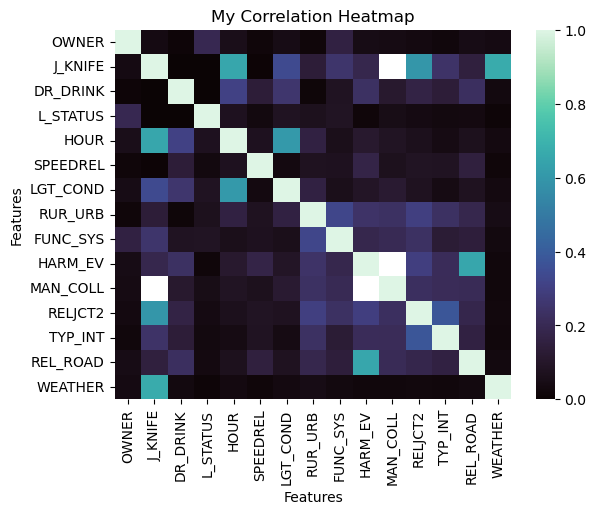

In [33]:
ax1 = sns.heatmap(cramersVtable, cmap='mako' )
ax1.set_title("My Correlation Heatmap")
ax1.set_xlabel("Features")
ax1.set_ylabel("Features")
# 2. Display the plot
plt.show()


## Closer Look at apparent correlations

In [30]:
#J_KNIFE and HOUR
contingency_table = pd.crosstab(df['J_KNIFE'], df['HOUR'])
contingency_table

HOUR,early morning,evening,evening rush,late evening,midnight,morning rush,noon
J_KNIFE,,,,,,,
1.0,1,1,5,1,1,4,8
2.0,0,2,1,0,0,0,0


In [31]:
#J_KNIFE and WEATHER
contingency_table = pd.crosstab(df['J_KNIFE'], df['WEATHER'])
contingency_table

WEATHER,1.0,3.0,4.0,5.0
J_KNIFE,,,,
1.0,17,1,2,0
2.0,1,1,0,1


**Reflection**: J_Knife is apparently a very sparce feature, with only a few examples throughout the dataset. For this reason, it fails **Cochran's Rule**, which states that none of the cell counts can be equal to 0 and less than 20% can be less than 5. In this case, J_Knife fails both counts and should be removed as a feature going forward.<br>

In [34]:
df = df.drop('J_KNIFE', axis = 1)

## Mutual Information

**Mutual Information** is an effective approach for determining how much two features tell us about each other between 0 and 1, and it can be applied across both nominal and ordinal categories. 

In [35]:
#Code generated by Gemini, instructed to use the same structure as CreateCramer'sVTable() but for NMI

from sklearn.metrics import normalized_mutual_info_score
def calculate_nmi_matrix(df):
    # Ensure columns are unique to avoid ambiguity
    df = df.drop(['ST_CASE', 'VEH_NO'], axis=1)

    columns = df.columns
    nmi_matrix = pd.DataFrame(index=columns, columns=columns)
    
    for col_i in columns:
        for col_j in columns:
            # Select the series directly
            series_i = df[col_i]
            series_j = df[col_j]
            
            # Create a mask that is True only where BOTH series have valid data
            mask = series_i.notna() & series_j.notna()
            
            # Apply the mask to get 1D arrays
            clean_i = series_i[mask]
            clean_j = series_j[mask]
            
            # Calculate Normalized Mutual Information
            nmi = normalized_mutual_info_score(clean_i, clean_j)
            
            # Store the result
            nmi_matrix.loc[col_i, col_j] = nmi
            
    return nmi_matrix.astype(float)



In [36]:
# Execute with the dataframe
nmi_df = calculate_nmi_matrix(df)

C:\Users\Clayg\miniconda3\envs\mlproj\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\Clayg\miniconda3\envs\mlproj\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\Clayg\miniconda3\envs\mlproj\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\Clayg\miniconda3\envs\mlproj\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values f

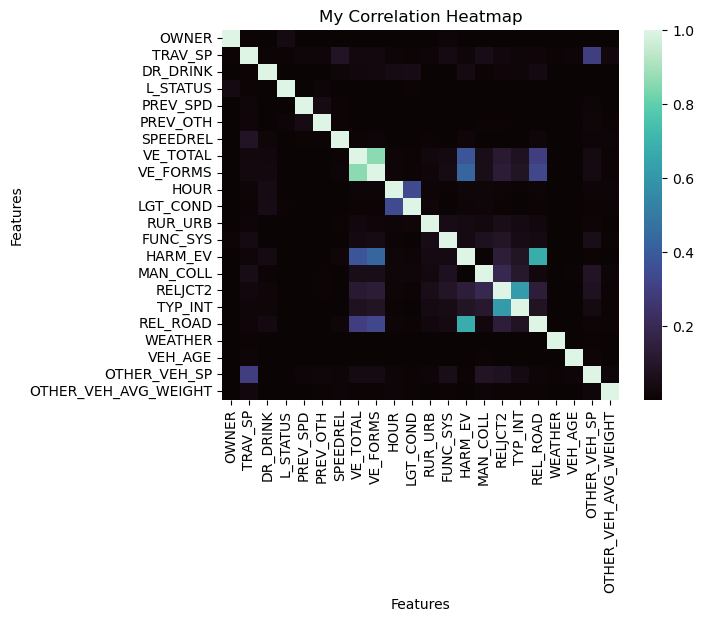

In [37]:
ax2 = sns.heatmap(nmi_df, cmap='mako', robust=True )
ax2.set_title("My Correlation Heatmap")
ax2.set_xlabel("Features")
ax2.set_ylabel("Features")
# 2. Display the plot
plt.show()


## Reflection: <br>
Once again we don't see any meaningful correlations between features. This doesn't bode particularly well for clustering. 

In [38]:
df.head()

,ST_CASE,VEH_NO,OWNER,J_KNIFE,TRAV_SP,DR_DRINK,L_STATUS,PREV_SPD,PREV_OTH,SPEEDREL,...,FUNC_SYS,HARM_EV,MAN_COLL,RELJCT2,TYP_INT,REL_ROAD,WEATHER,VEH_AGE,OTHER_VEH_SP,OTHER_VEH_AVG_WEIGHT
0,10087,1,2.0,NaN,60,1,1.0,2.0,1.0,1.0,...,3.0,1.0,NaN,1.0,1.0,3,4.0,30.0,<NA>,NaN
1,10114,1,1.0,NaN,<NA>,0,1.0,0.0,0.0,1.0,...,3.0,4.0,8.0,1.0,1.0,1,4.0,10.0,<NA>,NaN
2,10114,1,1.0,NaN,<NA>,0,1.0,0.0,0.0,1.0,...,3.0,4.0,8.0,1.0,1.0,1,4.0,10.0,30,18.0
3,10201,2,2.0,NaN,75,0,1.0,1.0,0.0,1.0,...,3.0,4.0,6.0,2.0,3.0,1,1.0,20.0,<NA>,NaN
4,10201,2,2.0,NaN,75,0,1.0,1.0,0.0,1.0,...,3.0,4.0,6.0,2.0,3.0,1,1.0,20.0,<NA>,NaN


In [38]:
#Save file for clustering steps

file_path_output = r"C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\CS-3120-Project\GeneratedData\\DataAnalysisFinal"
df.to_csv(file_path_output, index=False)
print(f"File successfully saved to: {file_path_output}")

File successfully saved to: C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\CS-3120-Project\GeneratedData\\DataAnalysisFinal
